# Image classification using CNN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets

In [2]:
import tarfile
import pickle
import os

# Extract
# tar_path = r"D:\Python\TensorFlow\cifar-10-python.tar.gz"
tar_path = "cifar-10-python.tar.gz"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall("cifar-10-data")


# Load batch
def load_batch(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="bytes")

    return data[b"data"], data[b"labels"]


data_dir = "cifar-10-data/cifar-10-batches-py"


# Training data
x_train = []
y_train = []

for i in range(1, 6):
    images, labels = load_batch(os.path.join(data_dir, f"data_batch_{i}"))

    x_train.append(images)
    y_train.extend(labels)


# Test data
x_test, y_test = load_batch(os.path.join(data_dir, "test_batch"))


x_train = np.concatenate(x_train)
y_train = np.array(y_train)

y_test = np.array(y_test)

# Reshape images
x_train = x_train.reshape(-1, 3, 32, 32)
x_test = x_test.reshape(-1, 3, 32, 32)

x_train = x_train.transpose(0, 2, 3, 1)
x_test = x_test.transpose(0, 2, 3, 1)


print("Training:", x_train.shape, y_train.shape)
print("Testing:", x_test.shape, y_test.shape)

C:\Users\USER\AppData\Local\Temp\ipykernel_1708\2389668390.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("cifar-10-data")


Training: (50000, 32, 32, 3) (50000,)
Testing: (10000, 32, 32, 3) (10000,)


In [3]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

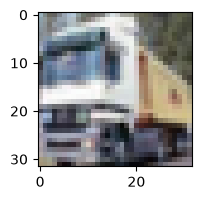

In [6]:
plt.figure(figsize=(15, 2))
plt.imshow(x_train[1])

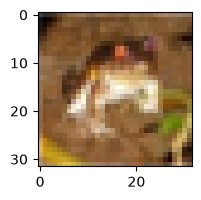

In [8]:
plt.figure(figsize=(15, 2))
plt.imshow(x_train[0])

In [11]:
y_train = y_train.reshape(
    -1,
)
y_train[:5]

array([6, 9, 9, 4, 1])

In [9]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [12]:
def plot_sample(x, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

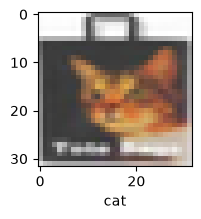

In [ ]:
plot_sample(x_train, y_train, 3000)

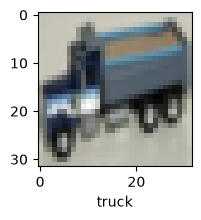

In [16]:
plot_sample(x_train, y_train, 340)

In [19]:
x_train = x_train / 255
x_test = x_test / 255

In [21]:
x_train.shape[1:]

(32, 32, 3)

In [23]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(32, 32, 3)),
        keras.layers.Dense(3000, activation="relu"),
        keras.layers.Dense(1000, activation="relu"),
        keras.layers.Dense(10, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="SGD", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 33ms/step - accuracy: 0.3524 - loss: 1.8144
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.4285 - loss: 1.6228
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4581 - loss: 1.5413
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.4774 - loss: 1.4815
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.4980 - loss: 1.4331


In [24]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4617 - loss: 1.5128


[1.512845516204834, 0.4616999924182892]

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)

y_pred_classes = [np.argmax(element) for element in y_pred]
y_true = y_test

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Confusion Matrix:
[[412  21  16  22  71  13  67 153 127  98]
 [ 19 468   3  21  22  27  46  79  37 278]
 [ 57  21 117  73 205  49 286 155  19  18]
 [  9   6  19 256  84 109 290 154  14  59]
 [ 26   3  17  31 429  15 292 150  18  19]
 [  4   7  21 163 104 254 247 157  19  24]
 [  1   5   6  39  79  15 790  41   7  17]
 [  8  12   8  38  74  31  94 685   5  45]
 [ 58  38   7  27  46  26  37  58 547 156]
 [ 12  91   4  27  16  19  53  97  22 659]]


In [29]:
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.41      0.51      1000
           1       0.70      0.47      0.56      1000
           2       0.54      0.12      0.19      1000
           3       0.37      0.26      0.30      1000
           4       0.38      0.43      0.40      1000
           5       0.46      0.25      0.33      1000
           6       0.36      0.79      0.49      1000
           7       0.40      0.69      0.50      1000
           8       0.67      0.55      0.60      1000
           9       0.48      0.66      0.56      1000

    accuracy                           0.46     10000
   macro avg       0.50      0.46      0.44     10000
weighted avg       0.50      0.46      0.44     10000



In [30]:
cnn = models.Sequential(
    [
        # cnn layers
        layers.Conv2D(
            filters=32, kernel_size=(3, 3), activation="relu", input_shape=(32, 32, 3)
        ),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPool2D((2, 2)),
        # dense layers
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

d:\Python\TensorFlow\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
cnn.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [32]:
cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4564 - loss: 1.5055
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5969 - loss: 1.1434
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6471 - loss: 1.0118
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6778 - loss: 0.9229
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7018 - loss: 0.8539
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7232 - loss: 0.8033
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7367 - loss: 0.7575
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7499 - loss: 0.7155
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7646 - loss: 0.6768
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7779 - loss: 0.6386


In [33]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6916 - loss: 0.9194


[0.9194403290748596, 0.6916000247001648]

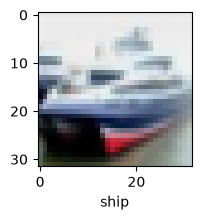

In [37]:
plot_sample(x_test, y_test, 1)

In [39]:
y_pred_cnn = cnn.predict(x_test)
np.argmax(y_pred_cnn[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


np.int64(8)

In [40]:
y_class = [np.argmax(element) for element in y_pred_cnn]

In [41]:
y_class[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(6)]

In [42]:
y_test[:5]

array([3, 8, 8, 0, 6])

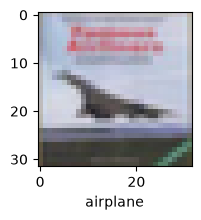

In [46]:
plot_sample(x_test, y_test, 3)

In [47]:
print("classification report:\n", classification_report(y_test, y_class))

classification report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      1000
           1       0.78      0.86      0.82      1000
           2       0.61      0.59      0.60      1000
           3       0.51      0.54      0.52      1000
           4       0.57      0.71      0.63      1000
           5       0.68      0.54      0.60      1000
           6       0.74      0.77      0.75      1000
           7       0.80      0.68      0.73      1000
           8       0.86      0.72      0.78      1000
           9       0.74      0.77      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000

